In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import re

In [2]:
df = pd.read_csv('../Data/CRX_fulllength_unified.csv')

No Change vs SLiM Removed: t=3.0280, p=2.4802e-03
No Change vs SLiM Added: t=6.4410, p=1.3859e-10


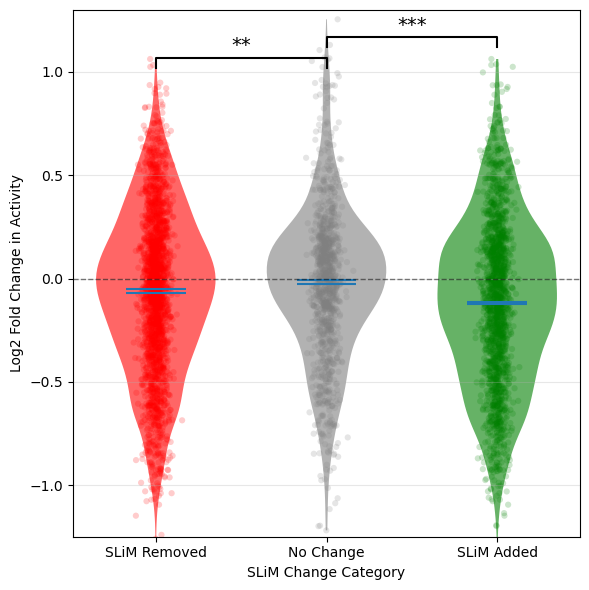

In [3]:
# Categorize mutations based on SLiM changes
# Allow multiple categories per row
def get_slim_categories(row):
    categories = []
    if row['SLiM_removed'] > 0:
        categories.append('SLiM Removed')
    if row['SLiM_added'] > 0:
        categories.append('SLiM Added')
    if row['SLiM_removed'] == 0 and row['SLiM_added'] == 0:
        categories.append('No Change')
    return categories

# Create the violin plot
fig, ax = plt.subplots(figsize=(6, 6))

# Prepare data for each category
categories = ['SLiM Removed', 'No Change', 'SLiM Added']
colors = ['red', 'grey', 'green']

# Collect data allowing duplicates and convert to log2 fold change
data = [[], [], []]
for idx, row in df.iterrows():
    cats = get_slim_categories(row)
    score = row['normalized_activity_score_mean']
    if pd.notna(score) and score > 0:  # Ensure positive value for log
        log2_fc = np.log2(score)
        for cat in cats:
            data[categories.index(cat)].append(log2_fc)

# Perform t-tests
# No Change vs SLiM Removed
t_stat_removed, p_val_removed = stats.ttest_ind(data[1], data[0])
# No Change vs SLiM Added
t_stat_added, p_val_added = stats.ttest_ind(data[1], data[2])

print(f"No Change vs SLiM Removed: t={t_stat_removed:.4f}, p={p_val_removed:.4e}")
print(f"No Change vs SLiM Added: t={t_stat_added:.4f}, p={p_val_added:.4e}")

# Create violin plot
parts = ax.violinplot(data, positions=[1, 2, 3], widths=0.7, showmeans=True, showmedians=True, showextrema=False)

# Color the violins
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

# Add raw data points with jitter
np.random.seed(42)  # For reproducibility
for i, (dataset, color) in enumerate(zip(data, colors)):
    # Add jitter to x-coordinates
    x_jitter = np.random.normal(i + 1, 0.04, size=len(dataset))
    ax.scatter(x_jitter, dataset, alpha=0.2, s=20, color=color, edgecolors='none')

# Add horizontal line at y=0 (no change)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add significance bars and annotations
y_max = max([max(d) for d in data])
bar_height = 1.02

# Bar for SLiM Removed vs No Change
ax.plot([1, 1, 2, 2], [bar_height, bar_height + 0.05, bar_height + 0.05, bar_height], 'k-', linewidth=1.5)
if p_val_removed < 0.001:
    ax.text(1.5, bar_height + 0.08, '***', ha='center', fontsize=14)
elif p_val_removed < 0.01:
    ax.text(1.5, bar_height + 0.08, '**', ha='center', fontsize=14)
elif p_val_removed < 0.05:
    ax.text(1.5, bar_height + 0.08, '*', ha='center', fontsize=14)
else:
    ax.text(1.5, bar_height + 0.08, 'ns', ha='center', fontsize=12)

# Bar for No Change vs SLiM Added
bar_height2 = bar_height + 0.1
ax.plot([2, 2, 3, 3], [bar_height2, bar_height2 + 0.05, bar_height2 + 0.05, bar_height2], 'k-', linewidth=1.5)
if p_val_added < 0.001:
    ax.text(2.5, bar_height2 + 0.08, '***', ha='center', fontsize=14)
elif p_val_added < 0.01:
    ax.text(2.5, bar_height2 + 0.08, '**', ha='center', fontsize=14)
elif p_val_added < 0.05:
    ax.text(2.5, bar_height2 + 0.08, '*', ha='center', fontsize=14)
else:
    ax.text(2.5, bar_height2 + 0.08, 'ns', ha='center', fontsize=12)

# Customize appearance
ax.set_ylim(-1.25, 1.3)
ax.set_ylabel('Log2 Fold Change in Activity')
ax.set_xlabel('SLiM Change Category')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(categories)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/s5/pmcccnjn3xscf5d6crplwgx40000gn/T/ipykernel_306/3788009414.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=categories, patch_artist=True, widths=0.6)


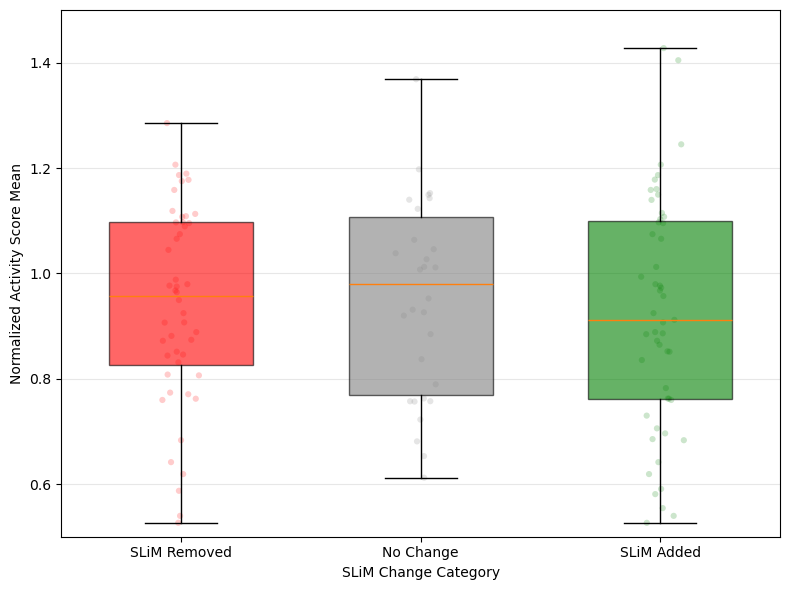

In [4]:
# Categorize mutations based on SLiM changes (only for in_clinvar == True)
# Allow multiple categories per row
def get_slim_categories(row):
    categories = []
    if row['SLiM_removed'] > 0:
        categories.append('SLiM Removed')
    if row['SLiM_added'] > 0:
        categories.append('SLiM Added')
    if row['SLiM_removed'] == 0 and row['SLiM_added'] == 0:
        categories.append('No Change')
    return categories

# Filter for only clinvar entries
df_clinvar = df[df['in_clinvar'] == True].copy()

# Create the boxplot
fig, ax = plt.subplots(figsize=(8, 6))

# Prepare data for each category
categories = ['SLiM Removed', 'No Change', 'SLiM Added']
colors = ['red', 'grey', 'green']

# Collect data allowing duplicates
data = [[], [], []]
for idx, row in df_clinvar.iterrows():
    cats = get_slim_categories(row)
    score = row['normalized_activity_score_mean']
    if pd.notna(score):
        for cat in cats:
            data[categories.index(cat)].append(score)

# Create boxplot
bp = ax.boxplot(data, labels=categories, patch_artist=True, widths=0.6)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Add raw data points with jitter
np.random.seed(42)  # For reproducibility
for i, (dataset, color) in enumerate(zip(data, colors)):
    # Add jitter to x-coordinates
    x_jitter = np.random.normal(i + 1, 0.04, size=len(dataset))
    ax.scatter(x_jitter, dataset, alpha=0.2, s=20, color=color, edgecolors='none')

# Customize appearance
ax.set_ylim(.5, 1.5)
ax.set_ylabel('Normalized Activity Score Mean')
ax.set_xlabel('SLiM Change Category')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/s5/pmcccnjn3xscf5d6crplwgx40000gn/T/ipykernel_306/3467749625.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=categories, patch_artist=True, widths=0.6)


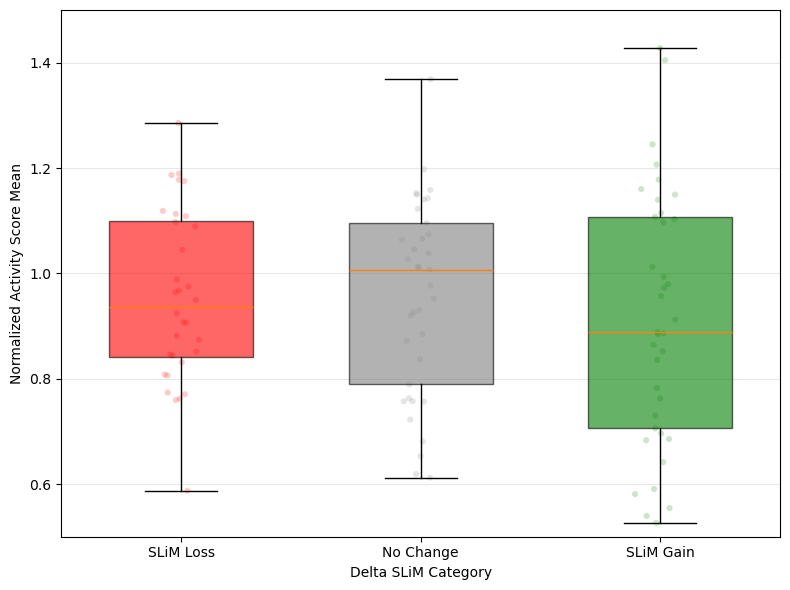

In [5]:
# Filter for only clinvar entries
df_clinvar = df[df['in_clinvar'] == True].copy()

# Categorize based on SLiM_delta
def categorize_delta_slim(row):
    delta = row['SLiM_delta']
    if pd.isna(delta):
        return None
    elif delta < 0:
        return 'SLiM Loss'
    elif delta == 0:
        return 'No Change'
    else:  # delta > 0
        return 'SLiM Gain'

df_clinvar['delta_category'] = df_clinvar.apply(categorize_delta_slim, axis=1)

# Create the boxplot
fig, ax = plt.subplots(figsize=(8, 6))

# Prepare data for each category
categories = ['SLiM Loss', 'No Change', 'SLiM Gain']
colors = ['red', 'grey', 'green']

# Collect data for each category
data = []
for cat in categories:
    cat_data = df_clinvar[df_clinvar['delta_category'] == cat]['normalized_activity_score_mean'].dropna().tolist()
    data.append(cat_data)

# Create boxplot
bp = ax.boxplot(data, labels=categories, patch_artist=True, widths=0.6)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Add raw data points with jitter
np.random.seed(42)  # For reproducibility
for i, (dataset, color) in enumerate(zip(data, colors)):
    # Add jitter to x-coordinates
    x_jitter = np.random.normal(i + 1, 0.04, size=len(dataset))
    ax.scatter(x_jitter, dataset, alpha=0.2, s=20, color=color, edgecolors='none')

# Customize appearance
ax.set_ylim(.5, 1.5)
ax.set_ylabel('Normalized Activity Score Mean')
ax.set_xlabel('Delta SLiM Category')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

No Change vs PTM Removed: t=5.8994, p=3.9737e-09
No Change vs PTM Added: t=1.8366, p=6.6363e-02


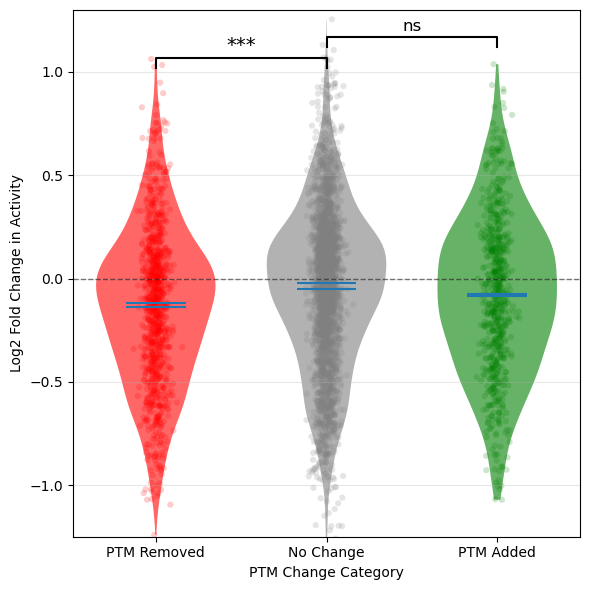

In [6]:
# Categorize mutations based on PTM changes
# Allow multiple categories per row
def get_ptm_categories(row):
    categories = []
    if row['MOD_removed'] > 0:
        categories.append('PTM Removed')
    if row['MOD_added'] > 0:
        categories.append('PTM Added')
    if row['MOD_removed'] == 0 and row['MOD_added'] == 0:
        categories.append('No Change')
    return categories

# Create the violin plot
fig, ax = plt.subplots(figsize=(6, 6))

# Prepare data for each category
categories = ['PTM Removed', 'No Change', 'PTM Added']
colors = ['red', 'grey', 'green']

# Collect data allowing duplicates and convert to log2 fold change
data = [[], [], []]
for idx, row in df.iterrows():
    cats = get_ptm_categories(row)
    score = row['normalized_activity_score_mean']
    if pd.notna(score) and score > 0:  # Ensure positive value for log
        log2_fc = np.log2(score)
        for cat in cats:
            data[categories.index(cat)].append(log2_fc)

# Perform t-tests
# No Change vs PTM Removed
t_stat_removed, p_val_removed = stats.ttest_ind(data[1], data[0])
# No Change vs PTM Added
t_stat_added, p_val_added = stats.ttest_ind(data[1], data[2])

print(f"No Change vs PTM Removed: t={t_stat_removed:.4f}, p={p_val_removed:.4e}")
print(f"No Change vs PTM Added: t={t_stat_added:.4f}, p={p_val_added:.4e}")

# Create violin plot
parts = ax.violinplot(data, positions=[1, 2, 3], widths=0.7, showmeans=True, showmedians=True, showextrema=False)

# Color the violins
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

# Add raw data points with jitter
np.random.seed(42)  # For reproducibility
for i, (dataset, color) in enumerate(zip(data, colors)):
    # Add jitter to x-coordinates
    x_jitter = np.random.normal(i + 1, 0.04, size=len(dataset))
    ax.scatter(x_jitter, dataset, alpha=0.2, s=20, color=color, edgecolors='none')

# Add horizontal line at y=0 (no change)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add significance bars and annotations
y_max = max([max(d) for d in data])
bar_height = 1.02

# Bar for PTM Removed vs No Change
ax.plot([1, 1, 2, 2], [bar_height, bar_height + 0.05, bar_height + 0.05, bar_height], 'k-', linewidth=1.5)
if p_val_removed < 0.001:
    ax.text(1.5, bar_height + 0.08, '***', ha='center', fontsize=14)
elif p_val_removed < 0.01:
    ax.text(1.5, bar_height + 0.08, '**', ha='center', fontsize=14)
elif p_val_removed < 0.05:
    ax.text(1.5, bar_height + 0.08, '*', ha='center', fontsize=14)
else:
    ax.text(1.5, bar_height + 0.08, 'ns', ha='center', fontsize=12)

# Bar for No Change vs PTM Added
bar_height2 = bar_height + 0.1
ax.plot([2, 2, 3, 3], [bar_height2, bar_height2 + 0.05, bar_height2 + 0.05, bar_height2], 'k-', linewidth=1.5)
if p_val_added < 0.001:
    ax.text(2.5, bar_height2 + 0.08, '***', ha='center', fontsize=14)
elif p_val_added < 0.01:
    ax.text(2.5, bar_height2 + 0.08, '**', ha='center', fontsize=14)
elif p_val_added < 0.05:
    ax.text(2.5, bar_height2 + 0.08, '*', ha='center', fontsize=14)
else:
    ax.text(2.5, bar_height2 + 0.08, 'ns', ha='center', fontsize=12)

# Customize appearance
ax.set_ylim(-1.25, 1.3)
ax.set_ylabel('Log2 Fold Change in Activity')
ax.set_xlabel('PTM Change Category')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(categories)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

No Change vs DEG Removed: t=-4.9605, p=7.3176e-07
No Change vs DEG Added: t=1.2080, p=2.2712e-01


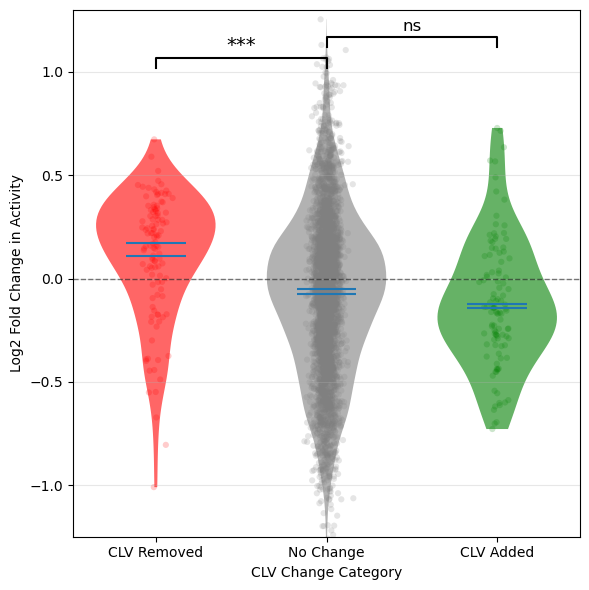

In [7]:
# Categorize mutations based on DEG changes
# Allow multiple categories per row
def get_deg_categories(row):
    categories = []
    if row['CLV_removed'] > 0:
        categories.append('CLV Removed')
    if row['CLV_added'] > 0:
        categories.append('CLV Added')
    if row['CLV_removed'] == 0 and row['CLV_added'] == 0:
        categories.append('No Change')
    return categories

# Create the violin plot
fig, ax = plt.subplots(figsize=(6, 6))

# Prepare data for each category
categories = ['CLV Removed', 'No Change', 'CLV Added']
colors = ['red', 'grey', 'green']

# Collect data allowing duplicates and convert to log2 fold change
data = [[], [], []]
for idx, row in df.iterrows():
    cats = get_deg_categories(row)
    score = row['normalized_activity_score_mean']
    if pd.notna(score) and score > 0:  # Ensure positive value for log
        log2_fc = np.log2(score)
        for cat in cats:
            data[categories.index(cat)].append(log2_fc)

# Perform t-tests
# No Change vs DEG Removed
t_stat_removed, p_val_removed = stats.ttest_ind(data[1], data[0])
# No Change vs DEG Added
t_stat_added, p_val_added = stats.ttest_ind(data[1], data[2])

print(f"No Change vs DEG Removed: t={t_stat_removed:.4f}, p={p_val_removed:.4e}")
print(f"No Change vs DEG Added: t={t_stat_added:.4f}, p={p_val_added:.4e}")

# Create violin plot
parts = ax.violinplot(data, positions=[1, 2, 3], widths=0.7, showmeans=True, showmedians=True, showextrema=False)

# Color the violins
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

# Add raw data points with jitter
np.random.seed(42)  # For reproducibility
for i, (dataset, color) in enumerate(zip(data, colors)):
    # Add jitter to x-coordinates
    x_jitter = np.random.normal(i + 1, 0.04, size=len(dataset))
    ax.scatter(x_jitter, dataset, alpha=0.2, s=20, color=color, edgecolors='none')

# Add horizontal line at y=0 (no change)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add significance bars and annotations
y_max = max([max(d) for d in data])
bar_height = 1.02

# Bar for DEG Removed vs No Change
ax.plot([1, 1, 2, 2], [bar_height, bar_height + 0.05, bar_height + 0.05, bar_height], 'k-', linewidth=1.5)
if p_val_removed < 0.001:
    ax.text(1.5, bar_height + 0.08, '***', ha='center', fontsize=14)
elif p_val_removed < 0.01:
    ax.text(1.5, bar_height + 0.08, '**', ha='center', fontsize=14)
elif p_val_removed < 0.05:
    ax.text(1.5, bar_height + 0.08, '*', ha='center', fontsize=14)
else:
    ax.text(1.5, bar_height + 0.08, 'ns', ha='center', fontsize=12)

# Bar for No Change vs DEG Added
bar_height2 = bar_height + 0.1
ax.plot([2, 2, 3, 3], [bar_height2, bar_height2 + 0.05, bar_height2 + 0.05, bar_height2], 'k-', linewidth=1.5)
if p_val_added < 0.001:
    ax.text(2.5, bar_height2 + 0.08, '***', ha='center', fontsize=14)
elif p_val_added < 0.01:
    ax.text(2.5, bar_height2 + 0.08, '**', ha='center', fontsize=14)
elif p_val_added < 0.05:
    ax.text(2.5, bar_height2 + 0.08, '*', ha='center', fontsize=14)
else:
    ax.text(2.5, bar_height2 + 0.08, 'ns', ha='center', fontsize=12)

# Customize appearance
ax.set_ylim(-1.25, 1.3)
ax.set_ylabel('Log2 Fold Change in Activity')
ax.set_xlabel('CLV Change Category')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(categories)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

No Change vs DEG Removed: t=-4.0736, p=4.7174e-05
No Change vs DEG Added: t=7.5720, p=4.5353e-14


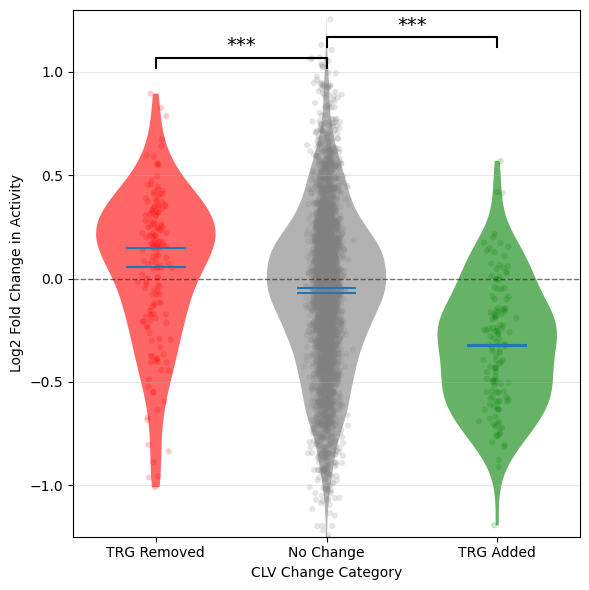

In [8]:
# Categorize mutations based on DEG changes
# Allow multiple categories per row
def get_deg_categories(row):
    categories = []
    if row['TRG_removed'] > 0:
        categories.append('TRG Removed')
    if row['TRG_added'] > 0:
        categories.append('TRG Added')
    if row['TRG_removed'] == 0 and row['TRG_added'] == 0:
        categories.append('No Change')
    return categories

# Create the violin plot
fig, ax = plt.subplots(figsize=(6, 6))

# Prepare data for each category
categories = ['TRG Removed', 'No Change', 'TRG Added']
colors = ['red', 'grey', 'green']

# Collect data allowing duplicates and convert to log2 fold change
data = [[], [], []]
for idx, row in df.iterrows():
    cats = get_deg_categories(row)
    score = row['normalized_activity_score_mean']
    if pd.notna(score) and score > 0:  # Ensure positive value for log
        log2_fc = np.log2(score)
        for cat in cats:
            data[categories.index(cat)].append(log2_fc)

# Perform t-tests
# No Change vs DEG Removed
t_stat_removed, p_val_removed = stats.ttest_ind(data[1], data[0])
# No Change vs DEG Added
t_stat_added, p_val_added = stats.ttest_ind(data[1], data[2])

print(f"No Change vs DEG Removed: t={t_stat_removed:.4f}, p={p_val_removed:.4e}")
print(f"No Change vs DEG Added: t={t_stat_added:.4f}, p={p_val_added:.4e}")

# Create violin plot
parts = ax.violinplot(data, positions=[1, 2, 3], widths=0.7, showmeans=True, showmedians=True, showextrema=False)

# Color the violins
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

# Add raw data points with jitter
np.random.seed(42)  # For reproducibility
for i, (dataset, color) in enumerate(zip(data, colors)):
    # Add jitter to x-coordinates
    x_jitter = np.random.normal(i + 1, 0.04, size=len(dataset))
    ax.scatter(x_jitter, dataset, alpha=0.2, s=20, color=color, edgecolors='none')

# Add horizontal line at y=0 (no change)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add significance bars and annotations
y_max = max([max(d) for d in data])
bar_height = 1.02

# Bar for DEG Removed vs No Change
ax.plot([1, 1, 2, 2], [bar_height, bar_height + 0.05, bar_height + 0.05, bar_height], 'k-', linewidth=1.5)
if p_val_removed < 0.001:
    ax.text(1.5, bar_height + 0.08, '***', ha='center', fontsize=14)
elif p_val_removed < 0.01:
    ax.text(1.5, bar_height + 0.08, '**', ha='center', fontsize=14)
elif p_val_removed < 0.05:
    ax.text(1.5, bar_height + 0.08, '*', ha='center', fontsize=14)
else:
    ax.text(1.5, bar_height + 0.08, 'ns', ha='center', fontsize=12)

# Bar for No Change vs DEG Added
bar_height2 = bar_height + 0.1
ax.plot([2, 2, 3, 3], [bar_height2, bar_height2 + 0.05, bar_height2 + 0.05, bar_height2], 'k-', linewidth=1.5)
if p_val_added < 0.001:
    ax.text(2.5, bar_height2 + 0.08, '***', ha='center', fontsize=14)
elif p_val_added < 0.01:
    ax.text(2.5, bar_height2 + 0.08, '**', ha='center', fontsize=14)
elif p_val_added < 0.05:
    ax.text(2.5, bar_height2 + 0.08, '*', ha='center', fontsize=14)
else:
    ax.text(2.5, bar_height2 + 0.08, 'ns', ha='center', fontsize=12)

# Customize appearance
ax.set_ylim(-1.25, 1.3)
ax.set_ylabel('Log2 Fold Change in Activity')
ax.set_xlabel('CLV Change Category')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(categories)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

No Change vs DEG Removed: t=-1.6279, p=1.0363e-01
No Change vs DEG Added: t=7.5082, p=7.7991e-14


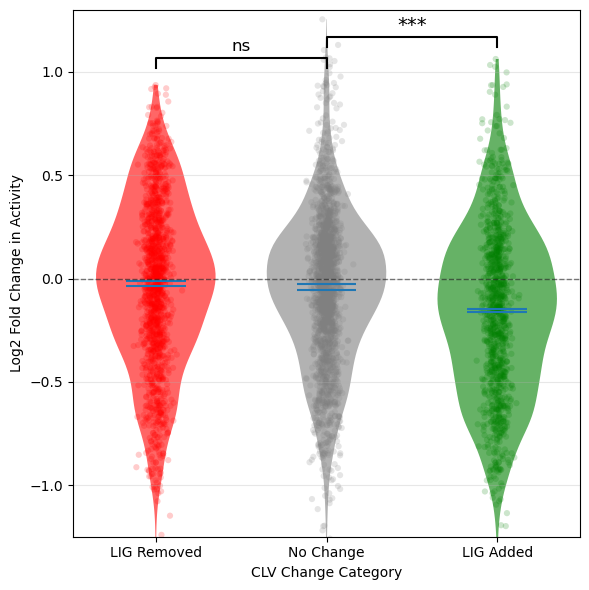

In [9]:
# Categorize mutations based on DEG changes
# Allow multiple categories per row
def get_deg_categories(row):
    categories = []
    if row['LIG_removed'] > 0:
        categories.append('LIG Removed')
    if row['LIG_added'] > 0:
        categories.append('LIG Added')
    if row['LIG_removed'] == 0 and row['LIG_added'] == 0:
        categories.append('No Change')
    return categories

# Create the violin plot
fig, ax = plt.subplots(figsize=(6, 6))

# Prepare data for each category
categories = ['LIG Removed', 'No Change', 'LIG Added']
colors = ['red', 'grey', 'green']

# Collect data allowing duplicates and convert to log2 fold change
data = [[], [], []]
for idx, row in df.iterrows():
    cats = get_deg_categories(row)
    score = row['normalized_activity_score_mean']
    if pd.notna(score) and score > 0:  # Ensure positive value for log
        log2_fc = np.log2(score)
        for cat in cats:
            data[categories.index(cat)].append(log2_fc)

# Perform t-tests
# No Change vs DEG Removed
t_stat_removed, p_val_removed = stats.ttest_ind(data[1], data[0])
# No Change vs DEG Added
t_stat_added, p_val_added = stats.ttest_ind(data[1], data[2])

print(f"No Change vs DEG Removed: t={t_stat_removed:.4f}, p={p_val_removed:.4e}")
print(f"No Change vs DEG Added: t={t_stat_added:.4f}, p={p_val_added:.4e}")

# Create violin plot
parts = ax.violinplot(data, positions=[1, 2, 3], widths=0.7, showmeans=True, showmedians=True, showextrema=False)

# Color the violins
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

# Add raw data points with jitter
np.random.seed(42)  # For reproducibility
for i, (dataset, color) in enumerate(zip(data, colors)):
    # Add jitter to x-coordinates
    x_jitter = np.random.normal(i + 1, 0.04, size=len(dataset))
    ax.scatter(x_jitter, dataset, alpha=0.2, s=20, color=color, edgecolors='none')

# Add horizontal line at y=0 (no change)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add significance bars and annotations
y_max = max([max(d) for d in data])
bar_height = 1.02

# Bar for DEG Removed vs No Change
ax.plot([1, 1, 2, 2], [bar_height, bar_height + 0.05, bar_height + 0.05, bar_height], 'k-', linewidth=1.5)
if p_val_removed < 0.001:
    ax.text(1.5, bar_height + 0.08, '***', ha='center', fontsize=14)
elif p_val_removed < 0.01:
    ax.text(1.5, bar_height + 0.08, '**', ha='center', fontsize=14)
elif p_val_removed < 0.05:
    ax.text(1.5, bar_height + 0.08, '*', ha='center', fontsize=14)
else:
    ax.text(1.5, bar_height + 0.08, 'ns', ha='center', fontsize=12)

# Bar for No Change vs DEG Added
bar_height2 = bar_height + 0.1
ax.plot([2, 2, 3, 3], [bar_height2, bar_height2 + 0.05, bar_height2 + 0.05, bar_height2], 'k-', linewidth=1.5)
if p_val_added < 0.001:
    ax.text(2.5, bar_height2 + 0.08, '***', ha='center', fontsize=14)
elif p_val_added < 0.01:
    ax.text(2.5, bar_height2 + 0.08, '**', ha='center', fontsize=14)
elif p_val_added < 0.05:
    ax.text(2.5, bar_height2 + 0.08, '*', ha='center', fontsize=14)
else:
    ax.text(2.5, bar_height2 + 0.08, 'ns', ha='center', fontsize=12)

# Customize appearance
ax.set_ylim(-1.25, 1.3)
ax.set_ylabel('Log2 Fold Change in Activity')
ax.set_xlabel('CLV Change Category')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(categories)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

No Change vs DEG Removed: t=5.9315, p=3.2622e-09
No Change vs DEG Added: t=2.0401, p=4.1408e-02


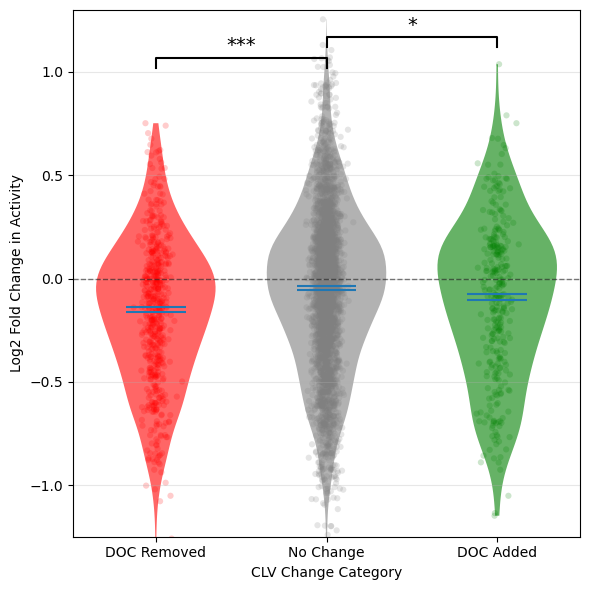

In [10]:
# Categorize mutations based on DEG changes
# Allow multiple categories per row
def get_deg_categories(row):
    categories = []
    if row['DOC_removed'] > 0:
        categories.append('DOC Removed')
    if row['DOC_added'] > 0:
        categories.append('DOC Added')
    if row['DOC_removed'] == 0 and row['DOC_added'] == 0:
        categories.append('No Change')
    return categories

# Create the violin plot
fig, ax = plt.subplots(figsize=(6, 6))

# Prepare data for each category
categories = ['DOC Removed', 'No Change', 'DOC Added']
colors = ['red', 'grey', 'green']

# Collect data allowing duplicates and convert to log2 fold change
data = [[], [], []]
for idx, row in df.iterrows():
    cats = get_deg_categories(row)
    score = row['normalized_activity_score_mean']
    if pd.notna(score) and score > 0:  # Ensure positive value for log
        log2_fc = np.log2(score)
        for cat in cats:
            data[categories.index(cat)].append(log2_fc)

# Perform t-tests
# No Change vs DEG Removed
t_stat_removed, p_val_removed = stats.ttest_ind(data[1], data[0])
# No Change vs DEG Added
t_stat_added, p_val_added = stats.ttest_ind(data[1], data[2])

print(f"No Change vs DEG Removed: t={t_stat_removed:.4f}, p={p_val_removed:.4e}")
print(f"No Change vs DEG Added: t={t_stat_added:.4f}, p={p_val_added:.4e}")

# Create violin plot
parts = ax.violinplot(data, positions=[1, 2, 3], widths=0.7, showmeans=True, showmedians=True, showextrema=False)

# Color the violins
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

# Add raw data points with jitter
np.random.seed(42)  # For reproducibility
for i, (dataset, color) in enumerate(zip(data, colors)):
    # Add jitter to x-coordinates
    x_jitter = np.random.normal(i + 1, 0.04, size=len(dataset))
    ax.scatter(x_jitter, dataset, alpha=0.2, s=20, color=color, edgecolors='none')

# Add horizontal line at y=0 (no change)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add significance bars and annotations
y_max = max([max(d) for d in data])
bar_height = 1.02

# Bar for DEG Removed vs No Change
ax.plot([1, 1, 2, 2], [bar_height, bar_height + 0.05, bar_height + 0.05, bar_height], 'k-', linewidth=1.5)
if p_val_removed < 0.001:
    ax.text(1.5, bar_height + 0.08, '***', ha='center', fontsize=14)
elif p_val_removed < 0.01:
    ax.text(1.5, bar_height + 0.08, '**', ha='center', fontsize=14)
elif p_val_removed < 0.05:
    ax.text(1.5, bar_height + 0.08, '*', ha='center', fontsize=14)
else:
    ax.text(1.5, bar_height + 0.08, 'ns', ha='center', fontsize=12)

# Bar for No Change vs DEG Added
bar_height2 = bar_height + 0.1
ax.plot([2, 2, 3, 3], [bar_height2, bar_height2 + 0.05, bar_height2 + 0.05, bar_height2], 'k-', linewidth=1.5)
if p_val_added < 0.001:
    ax.text(2.5, bar_height2 + 0.08, '***', ha='center', fontsize=14)
elif p_val_added < 0.01:
    ax.text(2.5, bar_height2 + 0.08, '**', ha='center', fontsize=14)
elif p_val_added < 0.05:
    ax.text(2.5, bar_height2 + 0.08, '*', ha='center', fontsize=14)
else:
    ax.text(2.5, bar_height2 + 0.08, 'ns', ha='center', fontsize=12)

# Customize appearance
ax.set_ylim(-1.25, 1.3)
ax.set_ylabel('Log2 Fold Change in Activity')
ax.set_xlabel('CLV Change Category')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(categories)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/s5/pmcccnjn3xscf5d6crplwgx40000gn/T/ipykernel_306/592381482.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Removed', 'No Change', 'Added'],
/var/folders/s5/pmcccnjn3xscf5d6crplwgx40000gn/T/ipykernel_306/592381482.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Removed', 'No Change', 'Added'],
/var/folders/s5/pmcccnjn3xscf5d6crplwgx40000gn/T/ipykernel_306/592381482.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Removed', 'No Change', 'Added'],
/var/folders/s5/pmcccnjn3xscf5d6crplwgx40000gn/T/ipyker

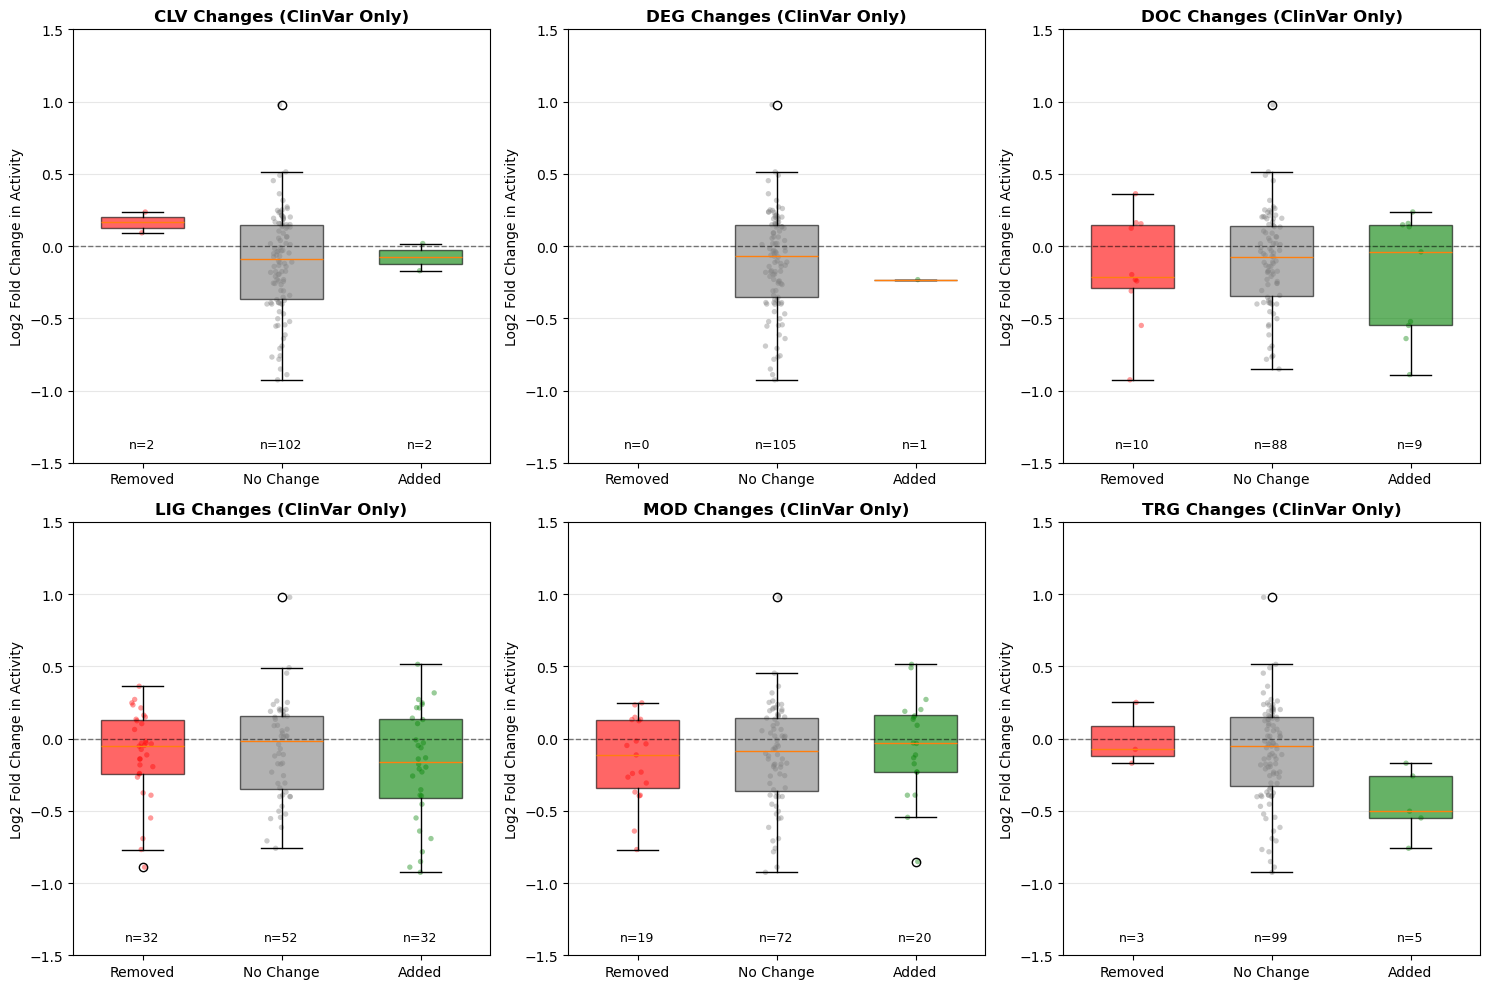

In [12]:
# Filter for only clinvar entries
df_clinvar = df[df['in_clinvar'] == True].copy()

# Create figure with 6 subplots (one for each motif type)
motif_types = ['CLV', 'DEG', 'DOC', 'LIG', 'MOD', 'TRG']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, motif in enumerate(motif_types):
    ax = axes[idx]
    
    # Categorize mutations based on this motif type
    def get_categories(row):
        categories = []
        if row[f'{motif}_removed'] > 0:
            categories.append(f'{motif} Removed')
        if row[f'{motif}_added'] > 0:
            categories.append(f'{motif} Added')
        if row[f'{motif}_removed'] == 0 and row[f'{motif}_added'] == 0:
            categories.append('No Change')
        return categories
    
    # Prepare data for each category
    categories = [f'{motif} Removed', 'No Change', f'{motif} Added']
    colors = ['red', 'grey', 'green']
    
    # Collect data allowing duplicates and convert to log2 fold change
    data = [[], [], []]
    for _, row in df_clinvar.iterrows():
        cats = get_categories(row)
        score = row['normalized_activity_score_mean']
        if pd.notna(score) and score > 0:  # Ensure positive value for log
            log2_fc = np.log2(score)
            for cat in cats:
                data[categories.index(cat)].append(log2_fc)
    
    # Create boxplot
    bp = ax.boxplot(data, labels=['Removed', 'No Change', 'Added'], 
                    patch_artist=True, widths=0.6)
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    # Add raw data points with jitter
    np.random.seed(42)
    for i, (dataset, color) in enumerate(zip(data, colors)):
        if len(dataset) > 0:
            x_jitter = np.random.normal(i + 1, 0.04, size=len(dataset))
            ax.scatter(x_jitter, dataset, alpha=0.4, s=15, color=color, edgecolors='none')
    
    # Add horizontal line at y=0
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Customize appearance
    ax.set_ylim(-1.5, 1.5)
    ax.set_ylabel('Log2 Fold Change in Activity')
    ax.set_title(f'{motif} Changes (ClinVar Only)', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add sample sizes
    for i, dataset in enumerate(data):
        ax.text(i + 1, -1.4, f'n={len(dataset)}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

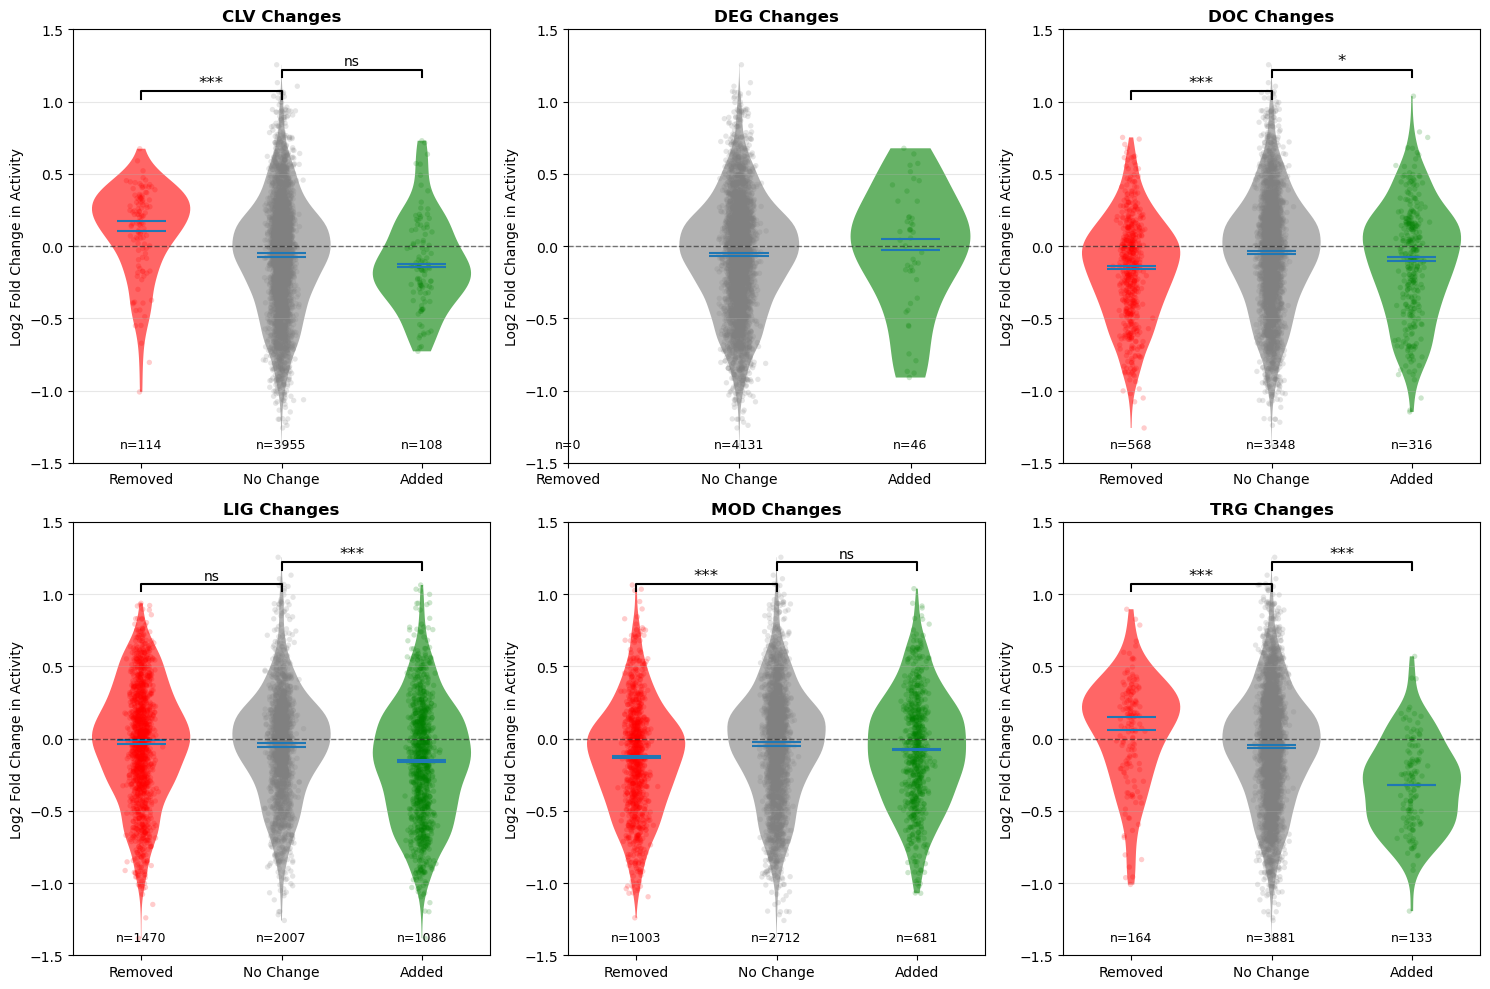

In [14]:
# Create figure with 6 subplots (one for each motif type)
motif_types = ['CLV', 'DEG', 'DOC', 'LIG', 'MOD', 'TRG']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, motif in enumerate(motif_types):
    ax = axes[idx]
    
    # Categorize mutations based on this motif type
    def get_categories(row):
        categories = []
        if row[f'{motif}_removed'] > 0:
            categories.append(f'{motif} Removed')
        if row[f'{motif}_added'] > 0:
            categories.append(f'{motif} Added')
        if row[f'{motif}_removed'] == 0 and row[f'{motif}_added'] == 0:
            categories.append('No Change')
        return categories
    
    # Prepare data for each category
    categories = [f'{motif} Removed', 'No Change', f'{motif} Added']
    colors = ['red', 'grey', 'green']
    
    # Collect data allowing duplicates and convert to log2 fold change
    data = [[], [], []]
    for _, row in df.iterrows():
        cats = get_categories(row)
        score = row['normalized_activity_score_mean']
        if pd.notna(score) and score > 0:  # Ensure positive value for log
            log2_fc = np.log2(score)
            for cat in cats:
                data[categories.index(cat)].append(log2_fc)
    
    # Filter out empty datasets and their corresponding positions/colors
    valid_data = []
    valid_positions = []
    valid_colors = []
    valid_labels = []
    
    for i, dataset in enumerate(data):
        if len(dataset) > 0:
            valid_data.append(dataset)
            valid_positions.append(i + 1)
            valid_colors.append(colors[i])
            valid_labels.append(['Removed', 'No Change', 'Added'][i])
    
    # Only create violin plot if we have data
    if len(valid_data) > 0:
        # Perform t-tests
        t_stat_removed, p_val_removed = stats.ttest_ind(data[1], data[0]) if len(data[0]) > 0 and len(data[1]) > 0 else (np.nan, np.nan)
        t_stat_added, p_val_added = stats.ttest_ind(data[1], data[2]) if len(data[2]) > 0 and len(data[1]) > 0 else (np.nan, np.nan)
        
        # Create violin plot
        parts = ax.violinplot(valid_data, positions=valid_positions, widths=0.7, 
                              showmeans=True, showmedians=True, showextrema=False)
        
        # Color the violins
        for pc, color in zip(parts['bodies'], valid_colors):
            pc.set_facecolor(color)
            pc.set_alpha(0.6)
        
        # Add raw data points with jitter
        np.random.seed(42)
        for pos, dataset, color in zip(valid_positions, valid_data, valid_colors):
            x_jitter = np.random.normal(pos, 0.04, size=len(dataset))
            ax.scatter(x_jitter, dataset, alpha=0.2, s=15, color=color, edgecolors='none')
        
        # Add horizontal line at y=0
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        
        # Add significance bars and annotations if there's data
        if not np.isnan(p_val_removed) and not np.isnan(p_val_added):
            bar_height = 1.02
            
            # Bar for Removed vs No Change
            ax.plot([1, 1, 2, 2], [bar_height, bar_height + 0.05, bar_height + 0.05, bar_height], 'k-', linewidth=1.5)
            if p_val_removed < 0.001:
                ax.text(1.5, bar_height + 0.08, '***', ha='center', fontsize=12)
            elif p_val_removed < 0.01:
                ax.text(1.5, bar_height + 0.08, '**', ha='center', fontsize=12)
            elif p_val_removed < 0.05:
                ax.text(1.5, bar_height + 0.08, '*', ha='center', fontsize=12)
            else:
                ax.text(1.5, bar_height + 0.08, 'ns', ha='center', fontsize=10)
            
            # Bar for No Change vs Added
            bar_height2 = bar_height + 0.15
            ax.plot([2, 2, 3, 3], [bar_height2, bar_height2 + 0.05, bar_height2 + 0.05, bar_height2], 'k-', linewidth=1.5)
            if p_val_added < 0.001:
                ax.text(2.5, bar_height2 + 0.08, '***', ha='center', fontsize=12)
            elif p_val_added < 0.01:
                ax.text(2.5, bar_height2 + 0.08, '**', ha='center', fontsize=12)
            elif p_val_added < 0.05:
                ax.text(2.5, bar_height2 + 0.08, '*', ha='center', fontsize=12)
            else:
                ax.text(2.5, bar_height2 + 0.08, 'ns', ha='center', fontsize=10)
    
    # Customize appearance
    ax.set_ylim(-1.5, 1.5)
    ax.set_ylabel('Log2 Fold Change in Activity')
    ax.set_title(f'{motif} Changes', fontweight='bold')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Removed', 'No Change', 'Added'])
    ax.grid(axis='y', alpha=0.3)
    
    # Add sample sizes
    for i, dataset in enumerate(data):
        ax.text(i + 1, -1.4, f'n={len(dataset)}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()